# MARS -- Material-Substitution Showcase

### Hierarchical Multi-Agent Reasoning for Knowledge-Grounded Material Substitution

**Set the query number in the config cell below, then Run All.** This notebook renders
any MARS run end-to-end — the requirements, the closed-loop search, the knowledge
subgraph, the manufacturing route, and (where available) the blind evaluation.

It auto-resolves where the data lives: it prefers the **frozen paper result**
(results_from_paper/QueryN/) when one exists, otherwise your **latest local run**
(results/QueryN/). When a query has several runs on disk, it always uses the
**latest** one.

In [125]:
# ══ CONFIG — change this, then Run All ══════════════════════════════
QUERY  = 3          # ← query number: 1, 2, 3, …
PREFER = "auto"     # "auto"  → frozen paper result if present, else latest local run
                    # "frozen"→ force results_from_paper/  |  "local" → force results/


### Resolving run data

In [126]:
# Setup — resolve data (latest run), load artifacts, design system
import json, html, re
from pathlib import Path
import numpy as np
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display
%matplotlib inline
esc = html.escape

def _find_root():
    # Walk up from cwd until we hit the repo root (has both config/ and src/) —
    # lets this notebook run whether Jupyter was launched from notebooks/ or repo root.
    for cand in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (cand / "config").is_dir() and (cand / "src").is_dir():
            return cand
    return Path.cwd().resolve()
ROOT = _find_root()
def _load(p):
    with open(p, encoding="utf-8") as f: return json.load(f)

QN = f"Query{QUERY}"
# Where to look for this query's data. "frozen" = curated paper results,
# "local" = your own pipeline runs. PREFER decides the search order; "auto" tries
# the frozen result first (the polished showcase) and falls back to a local run.
ROOTS = {"frozen": ROOT / "results_from_paper", "local": ROOT / "results"}
SEARCH = {"auto": ["frozen", "local"], "frozen": ["frozen"], "local": ["local"]}[PREFER]
DATA = SRC = None
for key in SEARCH:                       # take the first location that actually has a mars.json
    d = ROOTS[key] / QN
    if (d / "mars.json").exists():
        DATA, SRC = d, key; break
if DATA is None:
    raise FileNotFoundError(f"No mars.json for {QN} under {[str(ROOTS[k]/QN) for k in SEARCH]}")
IS_FROZEN = (SRC == "frozen")
ART = DATA / "artifacts"

mars = _load(DATA / "mars.json")

# ── pick the LATEST run on disk (run-ids are YYYYMMDDHH → lexical max = latest) ──
run_ids = sorted({p.stem.replace("pipeline_run_", "") for p in ART.glob("pipeline_run_*.json")})
RUN_ID = max(run_ids) if run_ids else str(mars["metadata"]["pipeline_run_id"])
N_RUNS = len(run_ids)
prun = ART / f"pipeline_run_{RUN_ID}.json"
pipe = _load(prun) if prun.exists() else _load(sorted(ART.glob("pipeline_run_*.json"))[-1])

# latest subgraph for this run (…{RUN_ID}_{iter}…); else any latest
sgs = sorted(ART.glob(f"subgraphs/{RUN_ID}_*_material_informed.json")) \
      or sorted(ART.glob("subgraphs/*_material_informed.json"))
subg = _load(sgs[-1])["data"] if sgs else {"nodes": [], "links": []}
CHATS = sorted(p for p in (ART / "chats").glob("*.json") if RUN_ID in p.name) \
        or sorted((ART / "chats").glob("*.json"))

# evaluation only if an aggregate covering THIS query exists under the chosen root
# (the blind LLM-judge comparison was only ever run for the paper's Query1 case study)
EVALF = ROOTS[SRC] / "evaluation" / "aggregate_results.json"
agg = _load(EVALF) if EVALF.exists() else None
HAS_EVAL = bool(agg) and any(pq.get("query_name") == QN for pq in agg.get("per_query", []))


### Defining HTML settings

In [ ]:
# ── design tokens (validated colorblind-safe palette; forced white surface) ──
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRID, LINE = "#ffffff", "#e1e0d9", "#c3c2b7"
ACCENT, GOOD, CRIT, WARN = "#2a78d6", "#0ca30c", "#d03b3b", "#eda100"
CAT = ["#2a78d6","#1baf7a","#eda100","#008300","#4a3aa7","#e34948","#e87ba4","#eb6834"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 11, "axes.edgecolor": LINE, "axes.linewidth": 0.8,
    "axes.grid": False, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.labelcolor": INK2, "text.color": INK, "svg.fonttype": "none",
})
# Force light-mode surfaces regardless of the notebook's dark/light theme — the report
# is designed as a fixed-appearance document, not a theme-aware app.
display(HTML("""<style>
.jp-RenderedMarkdown,.text_cell_render{background:#ffffff!important;color:#141414!important;border-radius:8px;padding:8px 14px;}
.jp-RenderedMarkdown *,.text_cell_render *{color:#141414!important;}
.jp-RenderedMarkdown a,.text_cell_render a{color:#1c5cab!important;}
.jp-RenderedMarkdown code,.text_cell_render code{background:#f2f2ef!important;color:#0b0b0b!important;}
.jp-RenderedMarkdown th,.jp-RenderedMarkdown td,.text_cell_render th,.text_cell_render td{border-color:#e1e0d9!important;}
.jp-OutputArea-output,.output_html,.jp-RenderedHTMLCommon{background:#ffffff!important;}
.m-wrap{font-family:system-ui,-apple-system,"Segoe UI",sans-serif;color:#0b0b0b;line-height:1.5;background:#ffffff;padding:14px 16px;border-radius:12px;}
.m-tiles{display:flex;gap:12px;flex-wrap:wrap;margin:8px 0;}
.m-tile{flex:1 1 130px;background:#fff;border:1px solid rgba(11,11,11,.08);border-radius:12px;padding:14px 16px;}
.m-tile .v{font-size:25px;font-weight:700;letter-spacing:-.02em;line-height:1.1;}
.m-tile .l{font-size:11px;color:#52514e;margin-top:4px;text-transform:uppercase;letter-spacing:.05em;}
.m-card{background:#fff;border:1px solid rgba(11,11,11,.08);border-radius:12px;padding:18px 20px;box-shadow:0 1px 2px rgba(11,11,11,.04);margin:10px 0;}
.m-h{font-size:12px;font-weight:700;text-transform:uppercase;letter-spacing:.07em;color:#52514e;margin:0 0 8px;}
.m-title{font-size:19px;font-weight:700;letter-spacing:-.02em;margin:2px 0 8px;}
.m-badge{display:inline-block;padding:3px 11px;border-radius:999px;font-size:12px;font-weight:700;vertical-align:middle;}
.m-good{background:rgba(12,163,12,.13);color:#0a7d0a;} .m-crit{background:rgba(208,59,59,.13);color:#b52e2e;}
.m-warn{background:rgba(237,161,0,.16);color:#8a6000;} .m-info{background:rgba(42,120,214,.13);color:#1c5cab;}
.m-list{margin:0;padding:0;list-style:none;} .m-list li{padding:7px 2px;border-bottom:1px solid #f0efec;font-size:13.5px;}
.m-term{font-weight:650;color:#0b0b0b;}
.m-2col{display:grid;grid-template-columns:1fr 1fr;gap:18px;}
.m-tl{position:relative;margin:4px 0 4px 8px;padding-left:26px;border-left:2px solid #e1e0d9;}
.m-node{position:relative;margin:0 0 14px;padding:12px 16px;background:#fff;border:1px solid rgba(11,11,11,.09);border-radius:10px;border-left-width:4px;}
.m-node:before{content:"";position:absolute;left:-33px;top:18px;width:11px;height:11px;border-radius:50%;background:#c3c2b7;border:2px solid #fff;}
.m-node .st{font-size:11px;font-weight:700;text-transform:uppercase;letter-spacing:.05em;color:#898781;}
table.m-tbl{border-collapse:collapse;width:100%;font-size:13px;}
.m-tbl th{text-align:left;color:#52514e;font-weight:600;border-bottom:2px solid #e1e0d9;padding:7px 10px;font-size:10.5px;text-transform:uppercase;letter-spacing:.05em;}
.m-tbl td{border-bottom:1px solid #f0efec;padding:8px 10px;vertical-align:top;} .m-tbl tr.hi td{background:rgba(42,120,214,.06);font-weight:600;}
details.m-det{background:#fff;border:1px solid rgba(11,11,11,.08);border-radius:10px;padding:7px 13px;margin:7px 0;}
details.m-det>summary{cursor:pointer;font-weight:600;color:#0b0b0b;list-style:none;} details.m-det>summary::-webkit-details-marker{display:none;}
.mono{font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-size:12px;white-space:pre-wrap;color:#333;}
.m-cap{font-size:12px;color:#898781;margin:6px 2px;} .pill{display:inline-block;font-size:10.5px;font-weight:700;padding:2px 8px;border-radius:6px;margin-right:6px;}
</style>"""))


### Defining rendering helpers

In [ ]:
def tiles(items):
    # items: (value, label) or (value, label, color) — a row of KPI-style stat cards
    out = []
    for it in items:
        v, l = it[0], it[1]; c = it[2] if len(it) > 2 else INK
        out.append(f'<div class="m-tile"><div class="v" style="color:{c}">{v}</div><div class="l">{l}</div></div>')
    return HTML('<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-tiles">' + "".join(out) + "</div></div>")

# ── prose(): render a markdown string as an inline-white HTML card ──
# A tiny markdown→HTML converter for the subset we use (headings, bold, inline
# code, links, bullet/numbered lists, tables, blockquotes, hr). Text is HTML-escaped
# first (so model output like "<10 cm" and ">200 %" is safe), then patterns applied.
def _md2html(t):
    def il(s):
        # inline formatting: escape first, then apply bold/code/link regexes to the
        # escaped text (safe because none of &<>" survive to collide with our markers)
        s = esc(s)
        s = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", s)
        s = re.sub(r"`([^`]+)`", r"<code>\1</code>", s)   # bare tag — styled by the global .m-wrap code CSS rule
        s = re.sub(r"\[([^\]]+)\]\(([^)]+)\)", r'<a href="\2" style="color:#1c5cab">\1</a>', s)
        return s
    L, out, i = t.split("\n"), [], 0
    while i < len(L):
        st = L[i].strip()
        if not st: i += 1; continue
        if st == "---":
            out.append('<hr style="border:none;border-top:1px solid #e1e0d9;margin:16px 0">'); i += 1; continue
        m = re.match(r"(#{1,6})\s+(.*)", st)          # heading
        if m:
            lv = len(m.group(1)); sz = {1: "22px", 2: "19px", 3: "15px"}.get(lv, "13px")
            out.append(f'<div style="font-weight:700;font-size:{sz};margin:{"18px" if lv<=2 else "12px"} 0 6px;color:#0b0b0b">{il(m.group(2))}</div>')
            i += 1; continue
        if st.startswith("> "):                        # blockquote
            buf = []
            while i < len(L) and L[i].strip().startswith(">"):
                buf.append(il(L[i].strip().lstrip(">").strip())); i += 1
            out.append('<div style="border-left:3px solid #c3c2b7;padding:6px 12px;margin:8px 0;color:#52514e;background:#faf9f7">' + "<br>".join(buf) + "</div>"); continue
        if st.startswith("|"):                          # table
            tb = []
            while i < len(L) and L[i].strip().startswith("|"): tb.append(L[i].strip()); i += 1
            rows = [[c.strip() for c in r.strip("|").split("|")] for r in tb]
            rows = [r for r in rows if not all(set(c) <= set("-: ") for c in r)]   # drop |---| separator
            if rows:
                th = "".join(f'<th style="text-align:left;border-bottom:2px solid #e1e0d9;padding:6px 10px;font-size:12px;color:#52514e">{il(c)}</th>' for c in rows[0])
                tr = "".join("<tr>" + "".join(f'<td style="border-bottom:1px solid #f0efec;padding:6px 10px;font-size:13px">{il(c)}</td>' for c in r) + "</tr>" for r in rows[1:])
                out.append(f'<table style="border-collapse:collapse;width:100%;margin:8px 0"><tr>{th}</tr>{tr}</table>')
            continue
        if re.match(r"(-|\*|\d+\.)\s+", st):            # bullet / numbered list
            od, items = bool(re.match(r"\d+\.\s+", st)), []
            while i < len(L) and re.match(r"(-|\*|\d+\.)\s+", L[i].strip()):
                items.append("<li style='margin:3px 0'>" + il(re.sub(r"^(-|\*|\d+\.)\s+", "", L[i].strip())) + "</li>"); i += 1
            tag = "ol" if od else "ul"
            out.append(f"<{tag} style='margin:6px 0 6px 4px;padding-left:22px'>" + "".join(items) + f"</{tag}>"); continue
        buf = []                                         # paragraph
        while i < len(L) and L[i].strip() and not re.match(r"(#{1,6}\s|>\s|\||-\s|\*\s|\d+\.\s|---)", L[i].strip()):
            buf.append(il(L[i].strip())); i += 1
        out.append(f'<p style="margin:8px 0;font-size:14px">{" ".join(buf)}</p>')
    return "".join(out)

def prose(t):
    style = ("background:#ffffff;color:#141414;font-family:system-ui,-apple-system,sans-serif;"
             "line-height:1.55;padding:16px 20px;border-radius:12px;border:1px solid rgba(11,11,11,.07);margin:6px 0")
    display(HTML(f'<div style="{style}">' + _md2html(t) + "</div>"))


In [127]:
q = mars["query"]
if IS_FROZEN:
    note = ('<span class="m-badge m-info">Frozen paper result</span> Loaded from '
            f'<code>{esc(str(DATA.relative_to(ROOT)))}</code> — produced with the full proprietary '
            'corpora and the <code>gpt-oss-20b</code> backbone; the exact output reported in the paper.')
else:
    note = ('<span class="m-badge m-warn">Local run</span> Loaded from '
            f'<code>{esc(str(DATA.relative_to(ROOT)))}</code> — a run on this machine using placeholder '
            '(dummy) retrieval corpora. The pipeline &amp; reasoning are real; the specific materials '
            'reflect the dummy inventory, not the proprietary corpora. That retrieval layer is the '
            'plug-in point for the real proprietary data.')
runsnote = f" · latest of {N_RUNS} runs on disk" if N_RUNS > 1 else ""
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card" style="border-left:4px solid {ACCENT}">
  <div class="m-h">{esc(QN)} &nbsp;·&nbsp; run {esc(RUN_ID)}{esc(runsnote)}</div>
  <div class="m-title">Replace: {esc(q['material_X'])}</div>
  <div style="font-size:13px;color:#52514e;margin-bottom:8px">for the context of <b>{esc(q['application_Y'])}</b></div>
  <div style="font-size:12.5px;color:#333">{note}</div></div></div>"""))


## 1 · The Task

The full natural-language query, split by System 1's front end into the target
material `X`, the application context `Y`, and the free-text intent.

In [128]:
# Count ALL non-empty items so the tiles match the numbered list below (render_reqs)
props = [p for p in mars["required_material_properties"]["properties"] if p.strip()]
cons  = [c for c in mars["required_material_properties"]["constraints"] if c.strip()]
meta  = mars["metadata"]; nrej = meta["total_rejected_candidates"]
statustxt = mars["manufacturing_process"]["status"].capitalize()
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card">
  <div class="m-h">Evaluation query</div><div style="font-size:15px;">{esc(q['sentence'])}</div></div></div>"""))
tiles([
    (len(props), "Required properties"), (len(cons), "Hard constraints"),
    (pipe["system2_system3_loop"]["total_iterations"], "S2↔S3 iterations"),
    (nrej, "Candidates rejected", CRIT if nrej else MUTED),
    (f"{pipe['total_duration_seconds']/60:.0f} min", "Wall-clock"),
    (statustxt, "Final verdict", GOOD if statustxt.lower() == "manufacturable" else CRIT),
])


## 2 · The MARS Architecture

Three cooperating agentic systems in a closed loop, each built from the same four
reusable agent roles — **Research Manager** (reasoning), **Analyst** (RAG),
**Scientist** (knowledge-graph traversal), **Assistant** (extraction).

| System | Job | Output |
|---|---|---|
| **1 · Requirements** | infer what the substitute must do | properties `W`, hard constraints `H` |
| **2 · Candidate generation** | propose a grounded, lab-available substitute | candidate `S` + evidence `E` |
| **3 · Manufacturability** | can it actually be made at lab scale? | recipe `P` **or** blocking constraints `C` → back to System 2 |


## 3 · System 1 — Requirements Analysis

System 1 decomposes the query into focused research questions, answers each with
dual text + KG retrieval, and distills the answers into the required properties `W`
and non-negotiable hard constraints `H` (shown verbatim below).

In [129]:
def render_reqs(items):
    # Number EVERY item (queries vary: some list terse phrases with no separator).
    # If an item has a term–detail separator, bold the term; otherwise show it whole.
    out = []
    for n, it in enumerate((x.strip() for x in items if x.strip()), 1):
        num = f'<span style="color:{ACCENT};font-weight:700;font-variant-numeric:tabular-nums;margin-right:8px">{n}.</span>'
        sep = next((s for s in ("–", "—", ":") if s in it), None)
        if sep:
            term, detail = it.split(sep, 1)
            body = (f'<span class="m-term">{esc(term.strip())}</span>'
                    f'<span style="color:#52514e"> — {esc(detail.strip())}</span>')
        else:
            body = f'<span class="m-term">{esc(it)}</span>'
        out.append(f'<li style="display:flex;gap:2px">{num}<span>{body}</span></li>')
    return '<ul class="m-list">' + "".join(out) + "</ul>"
P = mars["required_material_properties"]
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-2col">
  <div class="m-card"><div class="m-title">Required properties&nbsp;<span class="m-badge m-warn">W</span></div>{render_reqs(P['properties'])}</div>
  <div class="m-card"><div class="m-title">Hard constraints&nbsp;<span class="m-badge m-crit">H</span></div>{render_reqs(P['constraints'])}</div>
</div></div>"""))


## 4 · System 2 ⇄ System 3 — The Closed-Loop Search

System 2 proposes a grounded candidate; System 3 stress-tests manufacturability.
When System 3 **blocks** a candidate, its reasons feed back as new constraints and
the search resumes — the system *self-corrects*. Trace reconstructed from the run's
`pipeline_run` record.

In [130]:
loop = pipe["system2_system3_loop"]; rej = mars["candidate_selection"]["rejected_candidates"]
def tnode(stage, title, body, color, badge=None):
    # One timeline entry: a colored left border marks S1/proposal/blocked/accepted,
    # an optional pill badge calls out the verdict (MANUFACTURABLE / BLOCKED / FINAL).
    b = f'<span class="m-badge {badge[0]}" style="margin-left:8px">{badge[1]}</span>' if badge else ""
    return (f'<div class="m-node" style="border-left-color:{color}"><div class="st">{esc(stage)}</div>'
            f'<div style="font-weight:650;font-size:14.5px;margin:2px 0 4px">{esc(title)}{b}</div>'
            f'<div style="font-size:13px;color:#52514e">{body}</div></div>')
parts = [tnode("System 1", "Requirements extracted",
              f"{len(props)} required properties, {len(cons)} hard constraints → handed to System 2", MUTED)]
for it in loop["iterations"]:
    s2, s3, n = it["system2"], it["system3"], it["iteration"]
    parts.append(tnode(f"Iteration {n} · System 2", f"Proposes: {s2['candidate']}",
                       "Grounded in the lab-material database + Material-Informed Subgraph", ACCENT))
    if s3["status"] == "manufacturable":
        parts.append(tnode(f"Iteration {n} · System 3", "Manufacturability assessment",
                           "Evidence-supported lab-scale synthesis route confirmed.", GOOD, ("m-good", "✓ MANUFACTURABLE")))
    else:
        # Show only the first blocking reason (truncated) inline; the full set for every
        # rejected candidate is available below in the "All rejected candidates" table.
        bc = s3.get("blocking_constraints", [])
        reason = esc(bc[0].get("description", str(bc[0])) if isinstance(bc[0], dict) else str(bc[0]))[:240] if bc else ""
        parts.append(tnode(f"Iteration {n} · System 3", "Manufacturability assessment",
                           (reason or "Blocked.") + " &nbsp;→&nbsp; constraints fed back to System 2", CRIT, ("m-crit", "✕ BLOCKED")))
parts.append(tnode("Result", mars["candidate_selection"]["final_candidate"]["material_name"],
                   "Accepted substitute.", GOOD, ("m-good", "FINAL")))
if rej:
    rows = "".join(f'<tr><td style="width:60%">{esc(r["candidate"])}</td>'
                   f'<td><span class="pill" style="background:rgba(137,135,129,.15);color:#52514e">{esc(r["source"])}</span></td>'
                   f'<td style="font-size:12px;color:#52514e">{esc("; ".join(r["constraints_violated"])[:160]) or "—"}</td></tr>' for r in rej)
    extra = (f'<details class="m-det"><summary>All {len(rej)} rejected candidates</summary>'
             f'<table class="m-tbl" style="margin-top:8px"><tr><th>Candidate</th><th>Rejected by</th><th>Reason</th></tr>{rows}</table></details>')
else:
    extra = '<div class="m-cap">No candidates were rejected — MARS converged on its first proposal for this query.</div>'
display(HTML(f'<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-tl">{"".join(parts)}</div>{extra}</div>'))


Candidate,Rejected by,Reason
INFULEX PE/EVOH-TiO2/Thin EVOH Barrier Multilayer Shrink Tubing,feasibility,Oxygen permeability exceeds required limit (≤ 1 × 10⁻⁷ cm³·mm m⁻² s⁻¹)
Engage 030902 HEALTH+™ Polyolefin Elastomer Core + 3 µm EVOH Barrier with 1 wt% CB Antistatic and 1.5 wt% DEHA Plasticiz,feasibility,—


### The accepted substitute

The verbatim System 2 justification for the final candidate:

In [131]:
cand = mars["candidate_selection"]["final_candidate"]; just = cand["justification"]
if "Justification:" in just: just = just.split("Justification:", 1)[1].strip()
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card" style="border-left:4px solid {GOOD}">
  <div class="m-h">Final candidate S</div><div class="m-title">{esc(cand['material_name'])}</div></div></div>"""))
prose(just)   # model justification is markdown → render as white prose card


## 5 · The Knowledge Substrate — Material-Informed Subgraph

Before proposing, System 2 grounds the required properties and every lab material
onto two knowledge graphs (Material Properties + Patents), links them by shortest
paths, and merges semantically-equivalent nodes. This is the relational evidence
the Research Manager reasons over.

In [132]:
G = nx.DiGraph()
for nd in subg["nodes"]: G.add_node(nd["id"], **{k: v for k, v in nd.items() if k != "id"})
for e in subg.get("links", subg.get("edges", [])): G.add_edge(e["source"], e["target"], relation=e.get("relation", ""))
# Nodes carry a "source_kgs" list (which knowledge graph(s) they came from, since merged
# nodes can appear in both) — kgc counts nodes matching an arbitrary predicate over that list.
def kgc(pred): return sum(1 for _, d in G.nodes(data=True) if pred(d.get("source_kgs", [])))
tiles([
    (G.number_of_nodes(), "Nodes"), (G.number_of_edges(), "Edges (relations)"),
    (kgc(lambda s: "material_properties" in s and "patents" not in s), "Material-Props KG"),
    (kgc(lambda s: "patents" in s), "Patents KG"),
    (sum(1 for _, d in G.nodes(data=True) if "material" in str(d.get("type", "")).lower()), "Material nodes"),
])


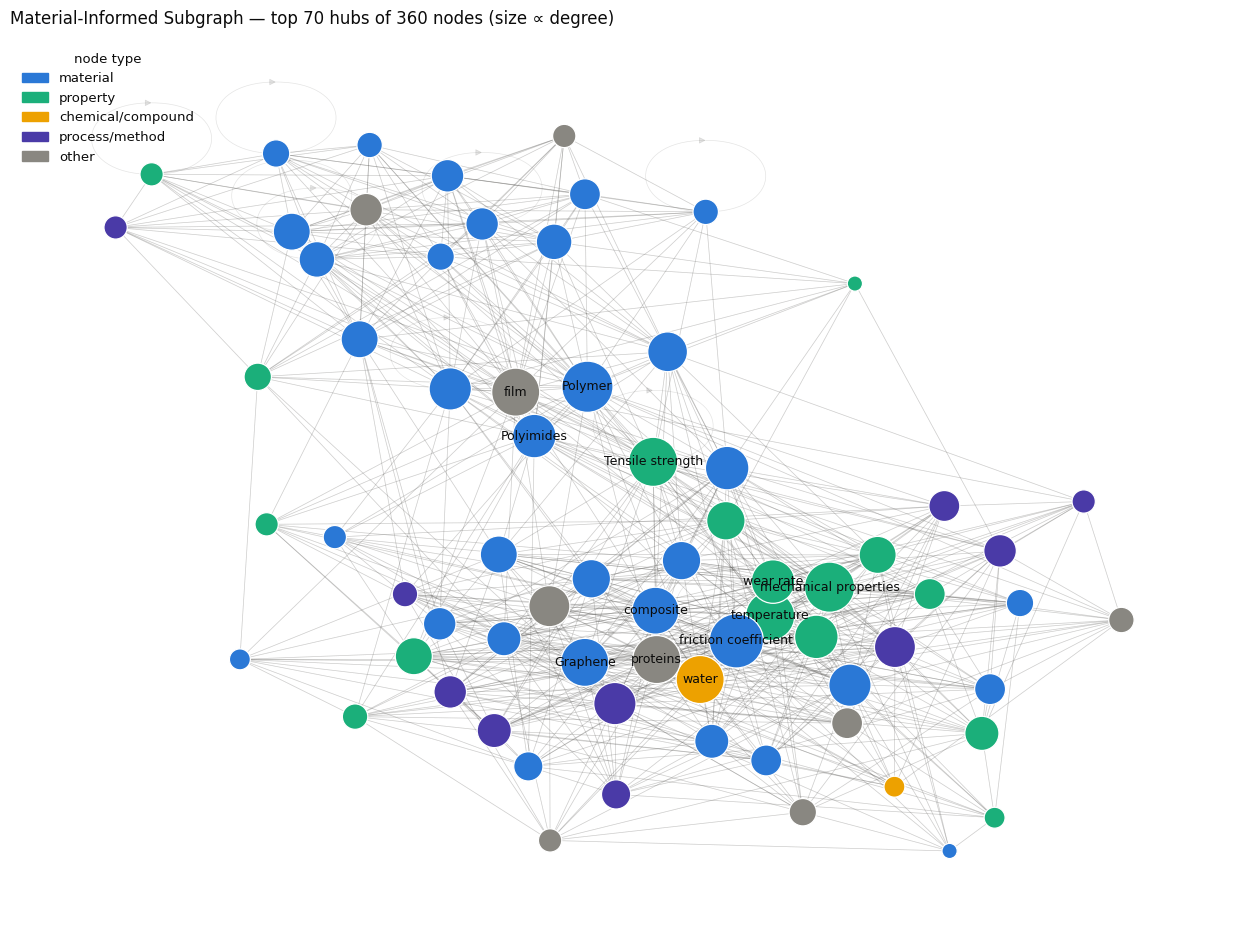

In [133]:
import matplotlib.patches as mp
TOP_N, SEED = 70, 42
# Coarse node-type buckets for coloring, matched by keyword against the node's "type"
# field (real KG node types are inconsistent free text, e.g. "material_sample" vs
# "polymer_component" — bucketing by substring keeps the legend to ~5 categories).
BUCKETS = [("material", CAT[0], ("material","component","sample","polymer","composite")),
           ("property", CAT[1], ("propert","parameter","strength","modulus")),
           ("chemical/compound", CAT[2], ("chemical","compound","substance","solvent")),
           ("process/method", CAT[4], ("process","method","technique","mechanism","treatment")),
           ("application", CAT[7], ("application","use"))]
def bucket(t):
    t = str(t).lower()
    for name, _c, keys in BUCKETS:
        if any(k in t for k in keys): return name
    return "other"
BCOL = {n: c for n, c, _ in BUCKETS}; BCOL["other"] = MUTED
def artifact(n, d):
    # Drop image/table nodes (e.g. embedded figure or table references from source docs) —
    # they clutter the layout and aren't part of the reasoning relationship graph.
    t = str(d.get("type", "")).lower()
    return t in ("image", "table") or str(n).lower().endswith((".png", ".jpg", ".jpeg"))
Gv = G.copy(); Gv.remove_nodes_from([n for n, d in G.nodes(data=True) if artifact(n, d)])
if Gv.number_of_nodes() >= 3:
    # Full subgraphs can run to hundreds of nodes — keep only the TOP_N highest-degree
    # ("hub") nodes so the force layout stays legible; the untrimmed graph lives in
    # graph_viz.ipynb for readers who want the whole thing.
    top = [n for n, _ in sorted(Gv.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]]
    H = Gv.subgraph(top).copy()
    bkt = {n: bucket(H.nodes[n].get("type", "")) for n in H.nodes}
    deg = np.array([H.degree(n) for n in H.nodes], float)
    nsz = 120 + 1400 * (deg - deg.min()) / (np.ptp(deg) + 1e-9)   # degree → marker size
    pos = nx.spring_layout(H, seed=SEED, k=2.0/np.sqrt(len(H)), iterations=80)
    fig, ax = plt.subplots(figsize=(12.5, 9.5))
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.16, width=0.5, edge_color="#5b5a57", arrows=False)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=[BCOL[bkt[n]] for n in H.nodes], node_size=nsz,
                           edgecolors="#ffffff", linewidths=0.9)
    hubs = [n for n, _ in sorted(H.degree(), key=lambda x: x[1], reverse=True)[:12]]
    nx.draw_networkx_labels(H, pos, {n: n for n in hubs}, ax=ax, font_size=9, font_color=INK)
    present = [b for b in [x[0] for x in BUCKETS] + ["other"] if b in set(bkt.values())]
    ax.legend(handles=[mp.Patch(color=BCOL[b], label=b) for b in present], loc="upper left",
              frameon=False, fontsize=9.5, title="node type", title_fontsize=9.5)
    ax.set_title(f"Material-Informed Subgraph — top {min(TOP_N, len(H))} hubs of {G.number_of_nodes()} nodes (size ∝ degree)",
                 fontsize=12, color=INK, loc="left", pad=12)
    ax.axis("off"); plt.tight_layout(); plt.show()
    display(HTML('<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-cap">Full graph in <code>graph_viz.ipynb</code>; the high-degree core is shown for legibility.</div></div>'))
else:
    display(HTML('<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-cap">Subgraph too small to visualize for this run.</div></div>'))


## 6 · System 3 — Manufacturability & Process Design

System 3 decomposes the candidate into constituents, retrieves process knowledge
from textbooks + patents + spec sheets, and emits a lab-scale process recipe `P`
(or blocking constraints).

In [134]:
mp_ = mars["manufacturing_process"]
badge = ('<span class="m-badge m-good">✓ Manufacturable</span>' if mp_["status"] == "manufacturable"
         else '<span class="m-badge m-crit">Blocked</span>')
def fmt_inputs(inp): return "—" if not inp else "<br>".join(f"• {esc(x)}" for x in inp)
# System 3 emits exactly one of these: a step-by-step recipe (manufacturable) or the
# blocking constraints that fed back into the System 2↔3 loop (see section 4 above).
if mp_.get("process_recipe"):
    rows = "".join(f'<tr><td style="text-align:center;font-weight:700;color:{ACCENT}">{s["step_index"]}</td>'
                   f'<td><b>{esc(s["description"])}</b></td>'
                   f'<td class="mono" style="font-size:11.5px">{esc(str(s.get("conditions") or "—"))}</td>'
                   f'<td style="font-size:12px;color:#52514e">{esc(s.get("equipment_class") or "—")}</td>'
                   f'<td style="font-size:12px">{fmt_inputs(s.get("inputs"))}</td></tr>' for s in mp_["process_recipe"])
    body = f'<table class="m-tbl"><tr><th>#</th><th>Step</th><th>Conditions</th><th>Equipment class</th><th>Inputs</th></tr>{rows}</table>'
else:
    bc = mp_.get("blocking_constraints", [])
    items = "".join(f"<li>{esc(b.get('description', str(b)) if isinstance(b, dict) else str(b))}</li>" for b in bc)
    body = f'<div class="m-h">Blocking constraints</div><ul>{items or "<li>—</li>"}</ul>'
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card"><div class="m-title">Lab-scale process recipe &nbsp;{badge}</div>{body}</div></div>"""))


#,Step,Conditions,Equipment class,Inputs
1,"Receive and store VESTAKEEP‑EVOH pellets in a temperature‑ and humidity‑controlled bulk silo (23 °C, 50 % RH) to prevent moisture absorption and degradation.",—,Bulk storage silo,—
2,Pre‑heat pellets in a continuous preheater tunnel to 90 °C for 30 s to reduce viscosity and remove surface moisture.,temperature: 90 °C; dwell_time: 30 s,Pellet preheater tunnel,• VESTAKEEP‑EVOH pellets
3,"Compounding and melt extrusion in a twin‑screw extruder (length‑to‑diameter ratio ≥ 30:1, full‑flight screw). Use a five‑zone temperature profile of 160–190 °C, screw speed 180–220 rpm, and a metering screw with a 5 mm diameter.",temperature_profile: 160–190 °C (zones 1‑5); screw_speed: 180–220 rpm; die_gap: 7 µm (flat film),Twin‑screw extruder,• Preheated VESTAKEEP‑EVOH pellets
4,Form a continuous flat film using a T‑die (gap 7 µm) and immediately cool on a chill roll set to 40–80 °C. Employ a thickness sensor (laser or laser‑scatter) to maintain 7 µm ±0.5 µm.,die_temperature: 180–190 °C; chill_roll_temperature: 40–80 °C; target_thickness: 7 µm,Flat‑film extrusion line (T‑die + chill roll),• Extruded polymer melt
5,Wind the continuous film onto a tension‑controlled spooling system with a tension profile of 0.5–1.0 N/m to avoid slack or over‑tightening.,—,Spooling system,• Cool‑film strip
6,Cut the wound film into 7 µm shrink‑bars using a continuous cutting die set to the desired bar width (typically 5–10 mm). Maintain cutting speed of 300–500 m/min with a water‑cooled blade.,cutting_speed: 300–500 m/min; blade_temperature: ≤ 50 °C,Continuous cutting die,• Spooled film strip
7,"Perform QC on a representative batch: measure film thickness (laser micrometer), perform 120 °C shrink‑test (10 min, 15 % shrinkage target), and tensile strength test (≥ 1.2 MPa). Reject any lot not meeting specifications.",—,Quality‑control laboratory,• Cut shrink‑bars
8,"Pack finished shrink‑bars onto 100 kg spools, seal with heat‑shrinkable film, and label with product code, batch, and expiry date.",—,Spool packing station,• QC‑approved shrink‑bars


## 7 · Evaluation — Blind LLM-as-Judge

Where available, MARS is compared against four reduced baselines: each produces the
same three standardized outputs, anonymized and shuffled to labels A–E, scored by an
independent judge (`gpt-4.1`) on 12 criteria (1–5), then unblinded.

In [135]:
if not HAS_EVAL:
    display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card">
      <div class="m-h">Not evaluated</div>
      <div style="font-size:13.5px;color:#333">The blind LLM-judge comparison was run for the paper's
      <b>Query1 (THV)</b> case study. It was not run for {esc(QN)}, so no comparative scores are shown.
      Set <code>QUERY = 1</code> above to see the full evaluation.</div></div></div>"""))
else:
    # Human-readable labels for the five compared configurations, and the 12 scoring
    # criteria grouped by which system they assess (4 criteria × 3 systems).
    LBL = {"evaluation":"MARS (full)","ablation_3agent":"3 LLM Calls (no RAG/KG)","ablation_1agent_rag":"1 LLM Call (w/ RAG/KG)",
           "ablation_1agent_no_rag":"1 LLM Call (no RAG/KG)","ablation_1agent_no_rag_openai":"1 LLM Call (GPT‑5.4)"}
    DIMS = {"System 1":["system1_completeness","system1_relevance","system1_scientific","system1_clarity"],
            "System 2":["system2_alignment","system2_novelty","system2_realism","system2_reasoning"],
            "System 3":["system3_plausibility","system3_practicality","system3_compatibility","system3_industrial"]}
    ALL = [d for dl in DIMS.values() for d in dl]
    pq = next(p for p in agg["per_query"] if p["query_name"] == QN)
    sc = {}
    for cond, dd in pq["scores"].items():
        sc[cond] = {d: (dd[d]["score"] if isinstance(dd[d], dict) else dd[d]) for d in ALL}
        # weighted_total isn't always present in older result files — fall back to a
        # plain mean of the 12 criteria so old and new eval JSON both render.
        sc[cond]["weighted_avg"] = dd.get("weighted_total", float(np.mean([sc[cond][d] for d in ALL])))
    order = sorted(sc, key=lambda c: sc[c]["weighted_avg"], reverse=True)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    vals = [sc[c]["weighted_avg"] for c in order]
    cols = [ACCENT if c == "evaluation" else MUTED for c in order]   # highlight MARS (full) only
    y = np.arange(len(order))[::-1]
    ax.barh(y, vals, color=cols, height=0.62, zorder=3)
    for yi, v in zip(y, vals): ax.text(v + 0.06, yi, f"{v:.2f}", va="center", fontsize=11, color=INK, fontweight="bold")
    ax.set_yticks(y); ax.set_yticklabels([LBL.get(c, c) for c in order], fontsize=10.5, color=INK)
    ax.set_xlim(0, 5); ax.set_xticks(range(6)); ax.set_xlabel("Overall score (mean of 12 criteria, 1–5)")
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.tick_params(length=0); ax.set_axisbelow(True); ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_title("Blind LLM-judge — overall ranking", fontsize=12, color=INK, loc="left", pad=10, fontweight="bold")
    plt.tight_layout(); plt.show()
    # Map score (2.5=neutral midpoint of the 1-5 scale) to a blue-tint intensity for the table cells.
    def tint(v): return f"background:rgba(42,120,214,{max(0.0,min(1.0,(v-2.5)/2.5))*0.34:.2f})"
    head = "".join(f"<th style='text-align:center'>{h}</th>" for h in ["Configuration","System 1","System 2","System 3","Total"])
    rows = []
    for c in order:
        subs = {k: float(np.mean([sc[c][d] for d in dl])) for k, dl in DIMS.items()}
        tot = sc[c]["weighted_avg"]; hi = " class='hi'" if c == "evaluation" else ""
        tc = "".join(f"<td style='text-align:center;{tint(subs[k])}'>{subs[k]:.2f}</td>" for k in DIMS)
        rows.append(f"<tr{hi}><td>{esc(LBL.get(c,c))}</td>{tc}<td style='text-align:center;font-weight:700;{tint(tot)}'>{tot:.2f}</td></tr>")
    display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card">
      <div class="m-h">Subsystem-level scores (judge: {esc(agg['judge_model'])}, seed {agg['seed']})</div>
      <table class="m-tbl"><tr>{head}</tr>{''.join(rows)}</table></div></div>"""))


## 8 · Under the Hood — Agent Reasoning Traces

Every agent turn is logged. Below: a summary of all logs, then a drill-down of each
system's trace (LLM prompts/responses, RAG queries, KG traversals) — this is what
makes MARS interpretable. Click any row to expand it.

In [136]:
def summ(p):
    d = json.load(open(p, encoding="utf-8")); return d, d.get("summary", {})
rows = []
for p in CHATS:
    _, s = summ(p); nm = p.name.replace("_chat_log", "").replace(".json", "")
    rows.append(f"<tr><td class='mono' style='font-size:11px'>{esc(nm)}</td>"
                f"<td style='text-align:center'>{s.get('llm_calls',0)}</td>"
                f"<td style='text-align:center'>{s.get('rag_queries',0)}</td>"
                f"<td style='text-align:center'>{s.get('kg_queries',0)}</td></tr>")
display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card"><div class="m-h">Reasoning logs for run {esc(RUN_ID)}</div>
  <table class="m-tbl"><tr><th>Log</th><th>LLM calls</th><th>RAG queries</th><th>KG queries</th></tr>{''.join(rows)}</table></div></div>"""))


Log,LLM calls,RAG queries,KG queries
system1_material_requirements_2026071718_0,11,6,4
system2_material_discovery_2026071718_0,55,34,1
system3_manufacturability_assessment_2026071718_0,9,63,0


### Rendering per-system reasoning traces

In [137]:
def render_trace(logpath, sysname):
    d, s = summ(logpath)
    def clip(t, n=None):   # show the FULL text — each interaction is a collapsed <details>, so nothing floods until expanded
        return esc((t or "").strip())
    PILL = {"llm":("rgba(42,120,214,.14)","#1c5cab"),"rag":("rgba(27,175,122,.16)","#127a55"),"kg":("rgba(74,58,167,.14)","#4a3aa7")}
    blocks = []
    for ix, itr in enumerate(d["interactions"], 1):
        t = itr["type"]; bg, fg = PILL.get(t, ("#eee", "#333")); dta = itr.get("data", {})
        head = (f'<span class="pill" style="background:{bg};color:{fg}">{t.upper()}</span>'
                f'<b>{esc(itr.get("agent",""))}</b> · <span style="color:#52514e">{esc(itr.get("method",""))}</span>')
        if t == "llm":
            inner = (f'<div class="m-h" style="margin-top:8px">User prompt</div><div class="mono">{clip(dta.get("user_prompt",""))}</div>'
                     f'<div class="m-h" style="margin-top:8px">Response</div><div class="mono">{clip(dta.get("response",""))}</div>')
        elif t == "rag":
            res = dta.get("results", []) or []
            # log stores the chunk text under "content_preview" (fall back to "content")
            def _rtxt(r): return r.get("content_preview") or r.get("content", "")
            docs = "".join(
                f'<div class="m-h" style="margin-top:8px">Result {j} · dist {r.get("distance"):.3f}</div>'
                f'<div class="mono">{clip(_rtxt(r))}</div>'
                if isinstance(r.get("distance"), (int, float)) else
                f'<div class="m-h" style="margin-top:8px">Result {j}</div><div class="mono">{clip(_rtxt(r))}</div>'
                for j, r in enumerate(res, 1)
            ) or '<div class="m-cap">No documents retrieved.</div>'
            inner = (f'<div style="margin-top:6px;font-size:12.5px"><b>Query:</b> {esc(dta.get("query",""))} · {dta.get("num_results",0)} results</div>'
                     f'{docs}')
        else:                                            # "kg" — knowledge-graph traversal
            inner = (f'<div style="margin-top:6px;font-size:12.5px"><b>Keywords:</b> {esc(", ".join(dta.get("keywords",[])))} · '
                     f'{dta.get("total_paths",0)} paths found</div>')
        blocks.append(f'<details class="m-det"><summary>{ix:>2}. {head}</summary>{inner}</details>')
    display(HTML(f"""<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card">
      <div class="m-title">{sysname} trace <span style="font-size:13px;color:#898781">{s.get('total_interactions',0)} interactions</span></div>
      <div style="font-size:13px;color:#52514e;margin-bottom:6px">{s.get('llm_calls',0)} LLM calls · {s.get('rag_queries',0)} RAG queries · {s.get('kg_queries',0)} KG traversals</div>
      {''.join(blocks)}</div></div>"""))

# One drill-down card per system. When a system ran over several iterations there are
# multiple logs — show the latest (the one behind the accepted candidate / final call).
for _label, _key in [("System 1", "system1"), ("System 2", "system2"), ("System 3", "system3")]:
    _m = [p for p in CHATS if _key in p.name]
    if _m:
        render_trace(_m[-1], _label)


## 9 · Timing Analysis — Wall-Clock by System

Where does MARS spend its time? Each run splits into **System 1** (requirements) and the **System 2 ⇄ 3 loop** (candidate generation + manufacturability), read from every run's `pipeline_run` record under `results/`. Across full-stack runs, **System 2 dominates (~70%)** and drives almost all the variance; System 1 and System 3 are near-constant. Failed runs (never reached System 2) are excluded.

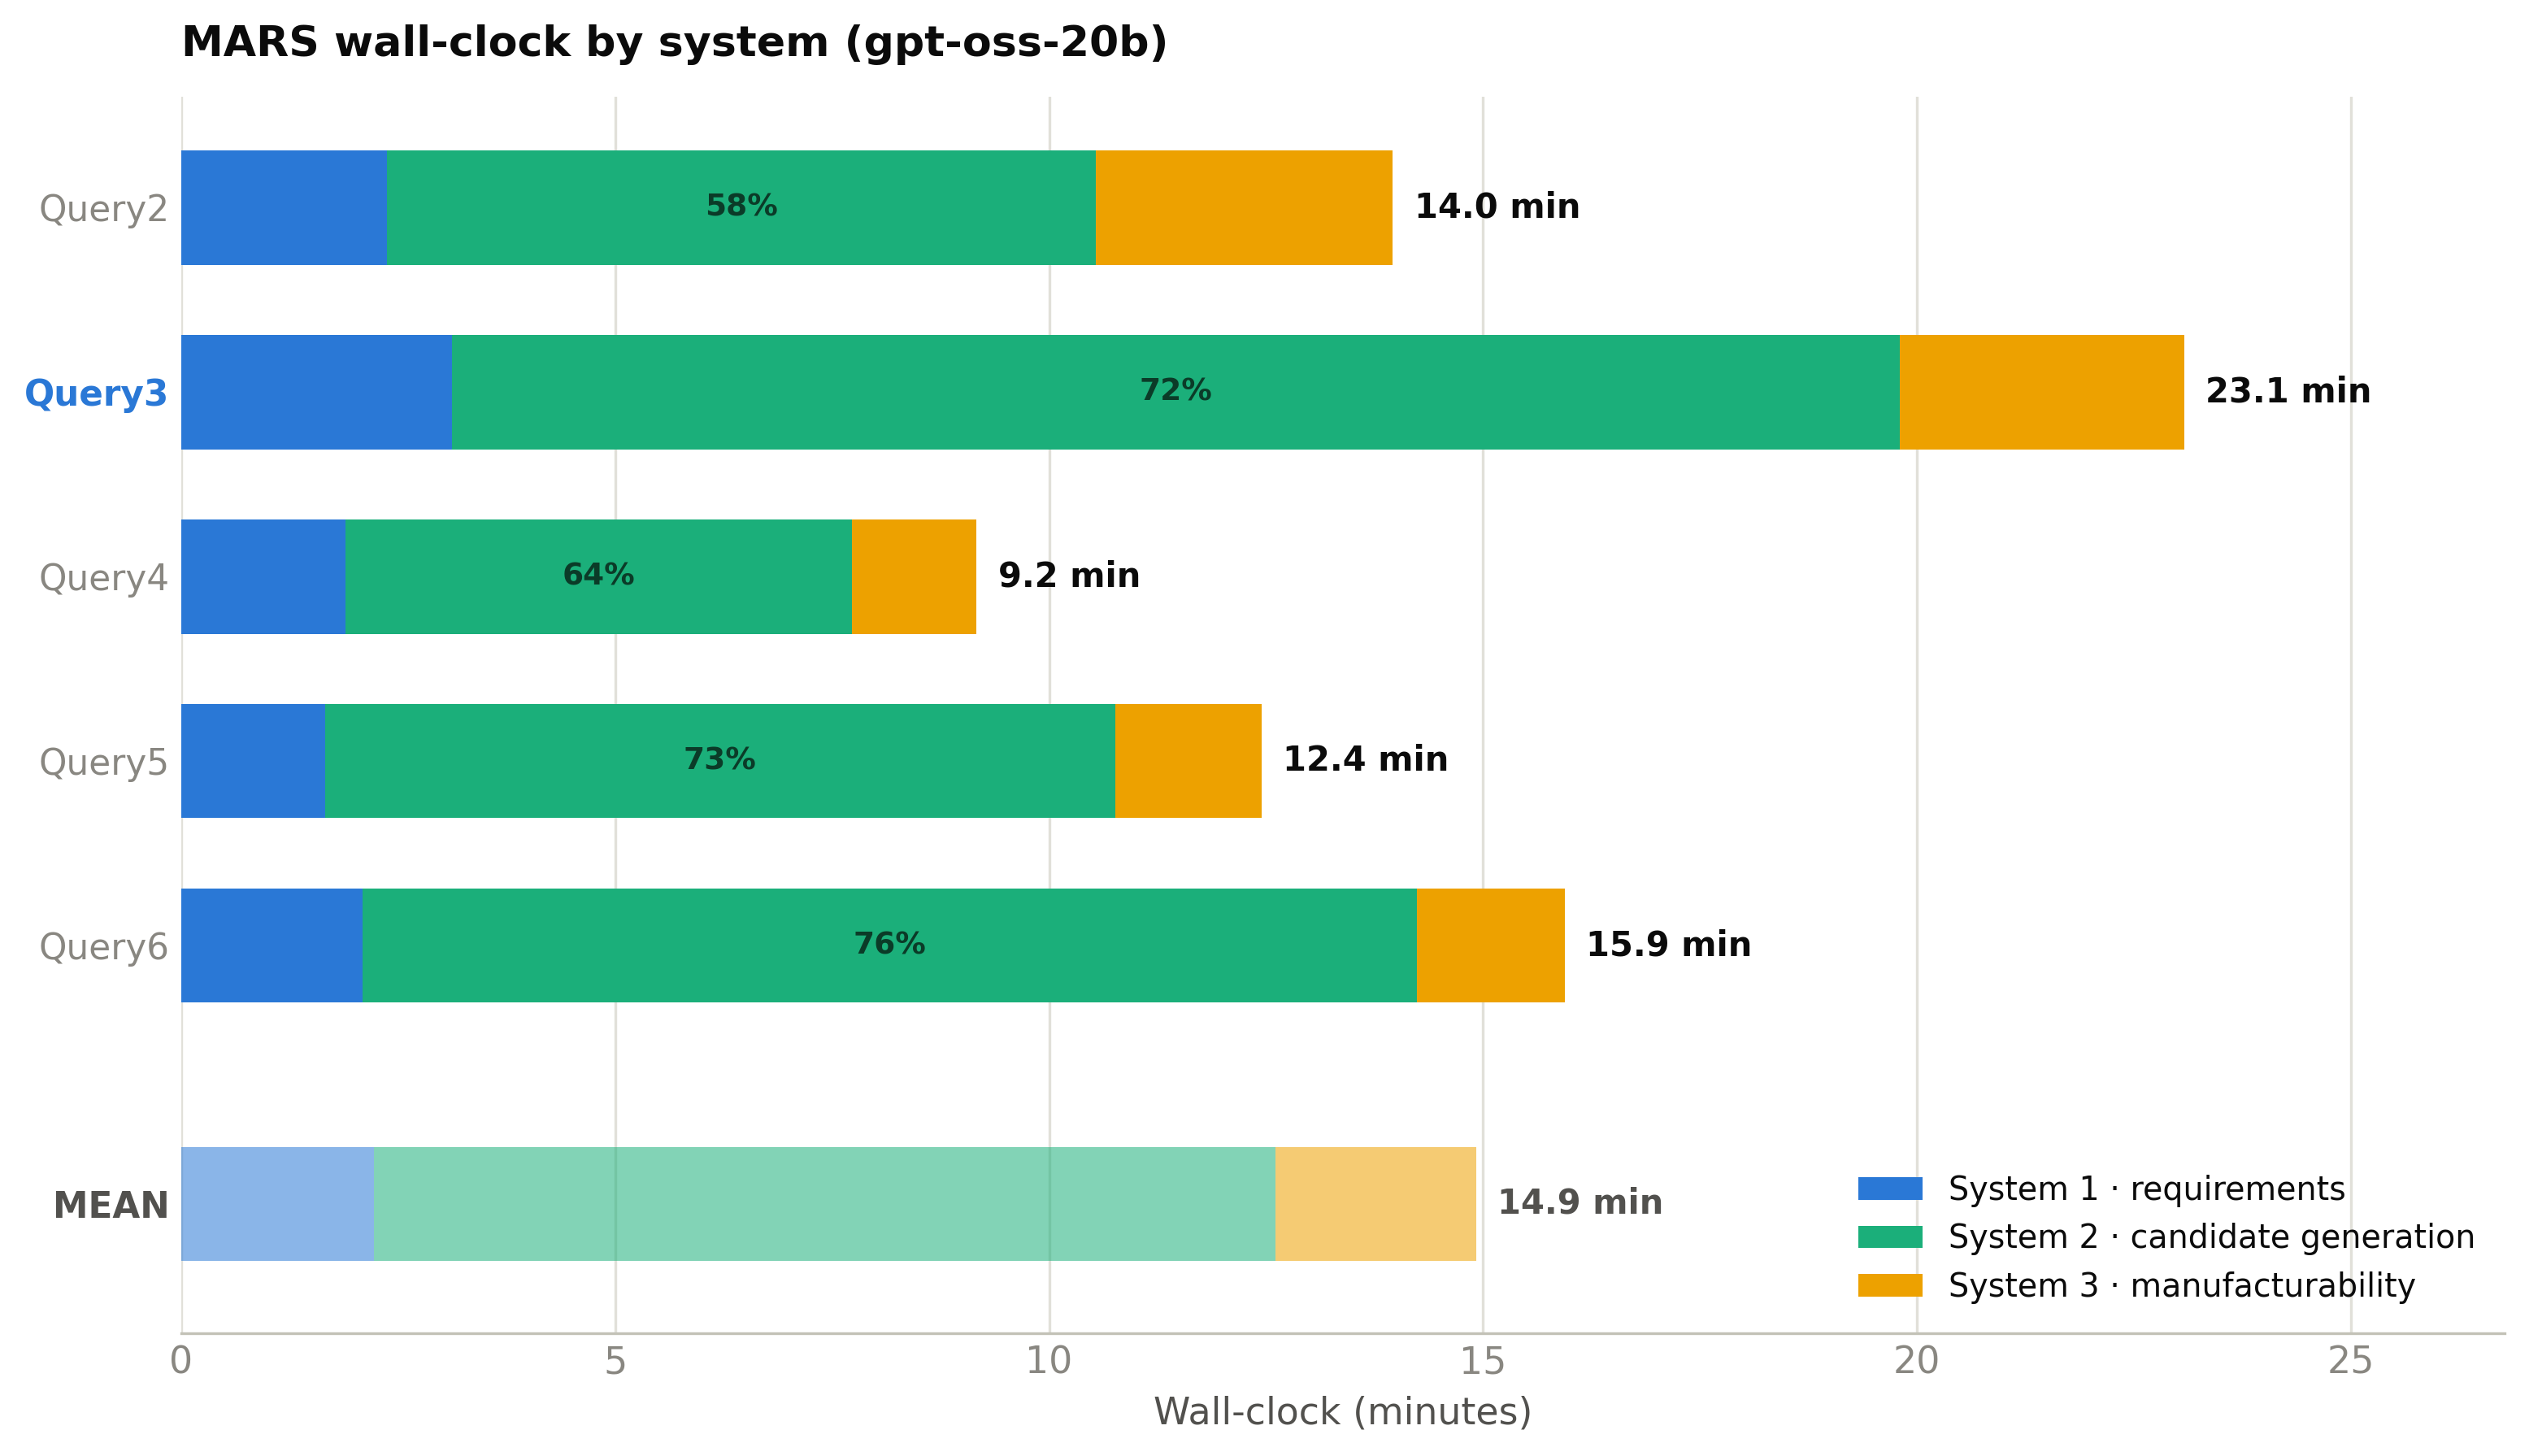

In [138]:
import glob, os

def _sys_minutes(qdir):
    prs = sorted(glob.glob(os.path.join(qdir, "artifacts", "pipeline_run_*.json")))
    if not prs:
        return None
    pr = _load(prs[-1])
    s1 = ((pr.get("system1") or {}).get("duration_seconds") or 0) / 60.0
    loop = pr.get("system2_system3_loop") or {}
    its = loop.get("iterations", []) or []
    s2 = sum(((it.get("system2") or {}).get("duration_seconds") or 0) for it in its) / 60.0
    s3 = sum(((it.get("system3") or {}).get("duration_seconds") or 0) for it in its) / 60.0
    return s1, s2, s3

runs = []
for qdir in sorted(glob.glob(str(ROOT / "results" / "Query*"))):
    nm = os.path.basename(qdir)
    if nm.endswith("_prevfull") or not os.path.isdir(qdir):
        continue
    d = _sys_minutes(qdir)
    if d and d[1] > 0:                      # keep only runs that reached System 2
        runs.append((nm, *d))

if not runs:
    display(HTML('<div class="m-wrap" style="background:#fff;color:#0b0b0b">'
                 '<div class="m-cap">No completed runs with timing data found under results/.</div></div>'))
else:
    # order top-to-bottom by query number: Query1, Query2, Query3, …
    def _qnum(nm):
        m = re.search(r"\d+", nm); return int(m.group()) if m else 10**9
    ordered = sorted(runs, key=lambda r: _qnum(r[0]))
    labels = [r[0] for r in ordered]
    s1 = np.array([r[1] for r in ordered]); s2 = np.array([r[2] for r in ordered]); s3 = np.array([r[3] for r in ordered])
    tot = s1 + s2 + s3
    m1, m2, m3 = s1.mean(), s2.mean(), s3.mean(); mt = m1 + m2 + m3

    C1, C2, C3 = ACCENT, "#1baf7a", "#eda100"            # S1 / S2 / S3 (colorblind-safe)
    n = len(ordered)
    y = np.arange(n)[::-1]                               # index 0 (Query1) → highest y → top
    y_mean = -1.4                                        # MEAN below everything, with a gap

    fig, ax = plt.subplots(figsize=(10.5, 0.62 * n + 3.0), dpi=300)
    ax.barh(y, s1, color=C1, height=0.62, zorder=3, label="System 1 · requirements")
    ax.barh(y, s2, left=s1, color=C2, height=0.62, zorder=3, label="System 2 · candidate generation")
    ax.barh(y, s3, left=s1 + s2, color=C3, height=0.62, zorder=3, label="System 3 · manufacturability")
    ax.barh(y_mean, m1, color=C1, height=0.62, zorder=3, alpha=0.55)
    ax.barh(y_mean, m2, left=m1, color=C2, height=0.62, zorder=3, alpha=0.55)
    ax.barh(y_mean, m3, left=m1 + m2, color=C3, height=0.62, zorder=3, alpha=0.55)

    for yi, t in zip(y, tot):
        ax.text(t + 0.25, yi, f"{t:.1f} min", va="center", fontsize=10, color=INK, fontweight="bold")
    ax.text(mt + 0.25, y_mean, f"{mt:.1f} min", va="center", fontsize=10, color=INK2, fontweight="bold")
    # System-2 share, printed inside its segment where it fits
    for i in range(n):
        if s2[i] > 3.5:
            ax.text(s1[i] + s2[i] / 2, y[i], f"{s2[i]/tot[i]*100:.0f}%", va="center", ha="center",
                    fontsize=9, color="#0b3b28", fontweight="bold")

    ax.set_yticks(list(y) + [y_mean]); ax.set_yticklabels(labels + ["MEAN"], fontsize=10.5)
    ax.set_ylim(y_mean - 0.7, (n - 1) + 0.6)            # MEAN at bottom, Query1 at top
    for tick in ax.get_yticklabels():
        if tick.get_text() == QN: tick.set_color(ACCENT); tick.set_fontweight("bold")
        if tick.get_text() == "MEAN": tick.set_color(INK2); tick.set_fontweight("bold")

    ax.set_xlabel("Wall-clock (minutes)"); ax.set_xlim(0, tot.max() * 1.16)
    for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
    ax.tick_params(length=0); ax.set_axisbelow(True); ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.legend(loc="lower right", frameon=False, fontsize=9.5)
    ax.set_title("MARS wall-clock by system (gpt-oss-20b)",
                 fontsize=12.5, color=INK, loc="left", pad=12, fontweight="bold")
    plt.tight_layout(); plt.show()

    share = f"System 1 {m1/mt*100:.0f}% · System 2 {m2/mt*100:.0f}% · System 3 {m3/mt*100:.0f}%"
    display(HTML(f'<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-cap">'
                 f'Mean of {n} completed run(s): {mt:.1f} min/query — {share}. '
                 f'System 2 (the propose→validate loop over real RAG) is the bottleneck and the main source of variance.'
                 f'</div></div>'))


## 10 · Agent Activity — Interactions by Agent Type

The same runs, now decomposed by **which agent** did the work — every logged interaction across Systems 1–3 (latest log per system), grouped by the four reusable roles: **Research Manager** (LLM reasoning), **Analyst** (RAG retrieval), **Scientist** (KG traversal), **Assistant** (extraction). The Manager dominates every run.

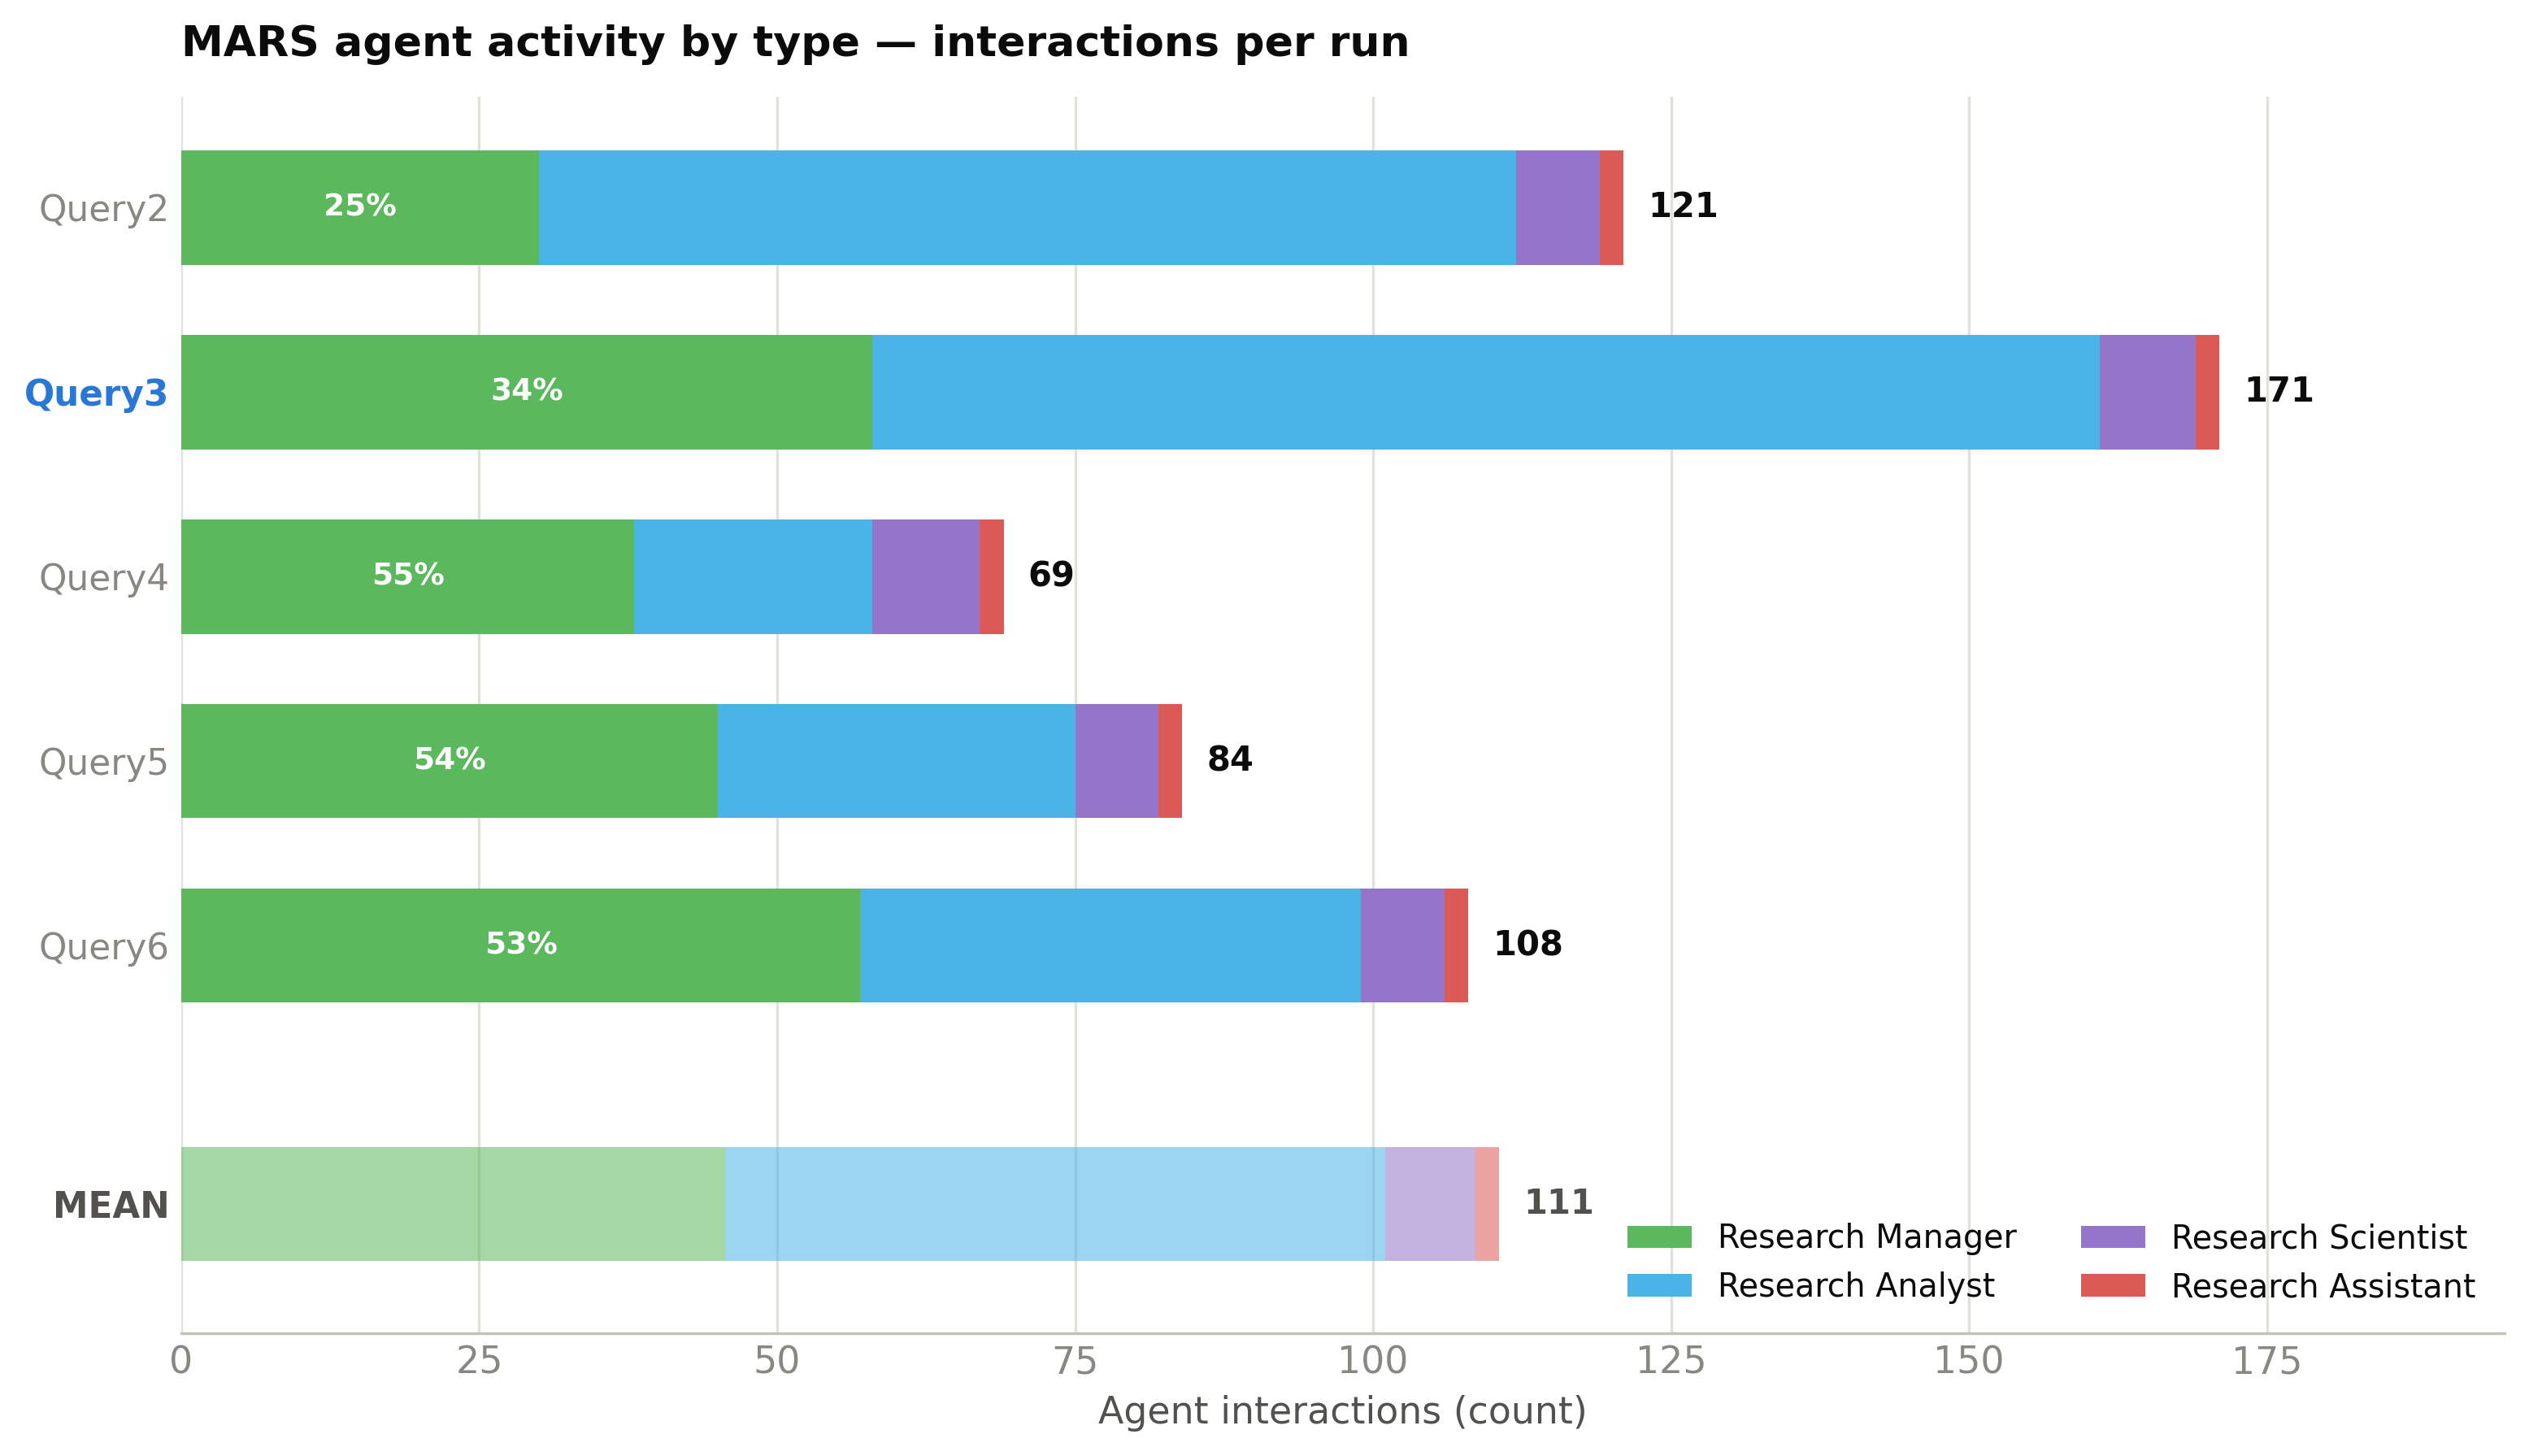

In [139]:
from collections import Counter

# Agent colours match the architecture figure: Manager=green, Analyst=blue, Scientist=purple, Assistant=red.
ROLES = [("research_manager",   "Research Manager",   "#5cb85c"),
         ("research_analyst",    "Research Analyst",   "#4bb4e6"),
         ("research_scientist",  "Research Scientist", "#9575c9"),
         ("research_assistant",  "Research Assistant", "#dc5a56")]
RKEYS = [r[0] for r in ROLES]

def _agent_counts(qdir):
    c = Counter()
    for s in ("system1", "system2", "system3"):        # latest log per system
        fs = sorted(glob.glob(os.path.join(qdir, "artifacts", "chats", f"{s}_*.json")))
        if not fs:
            continue
        for it in _load(fs[-1]).get("interactions", []):
            a = it.get("agent", "")
            if a in RKEYS:                              # only the four canonical roles
                c[a] += 1
    return c

arows = []
for qdir in sorted(glob.glob(str(ROOT / "results" / "Query*"))):
    nm = os.path.basename(qdir)
    if nm.endswith("_prevfull") or not os.path.isdir(qdir):
        continue
    # match the timing plot: only runs that reached System 2 (exclude failed runs)
    s2fs = sorted(glob.glob(os.path.join(qdir, "artifacts", "chats", "system2_*.json")))
    if not (s2fs and _load(s2fs[-1]).get("interactions")):
        continue
    c = _agent_counts(qdir)
    if sum(c.values()) > 0:
        arows.append((nm, c))

if not arows:
    display(HTML('<div class="m-wrap" style="background:#fff;color:#0b0b0b">'
                 '<div class="m-cap">No completed agent logs found under results/.</div></div>'))
else:
    arows.sort(key=lambda r: int(re.search(r"\d+", r[0]).group()))   # Query1, Query2, …
    labels = [r[0] for r in arows]; n = len(arows)
    cols = [r[2] for r in ROLES]
    labs = [r[1] for r in ROLES]
    M = np.array([[r[1].get(k, 0) for k in RKEYS] for r in arows], float)   # n × 4
    mean = M.mean(axis=0); tot = M.sum(axis=1)
    y = np.arange(n)[::-1]; y_mean = -1.4

    fig, ax = plt.subplots(figsize=(10.5, 0.62 * n + 3.0), dpi=300)
    left = np.zeros(n)
    for j, (col, lab) in enumerate(zip(cols, labs)):
        ax.barh(y, M[:, j], left=left, color=col, height=0.62, zorder=3,
                label=(lab if M[:, j].sum() > 0 else None))
        left += M[:, j]
    lm = 0.0
    for j, col in enumerate(cols):
        ax.barh(y_mean, mean[j], left=lm, color=col, height=0.62, zorder=3, alpha=0.55); lm += mean[j]

    for yi, t in zip(y, tot):
        ax.text(t + tot.max() * 0.012, yi, f"{int(t)}", va="center", fontsize=10, color=INK, fontweight="bold")
    ax.text(mean.sum() + tot.max() * 0.012, y_mean, f"{mean.sum():.0f}", va="center", fontsize=10, color=INK2, fontweight="bold")
    # Manager share, printed inside its (green) segment where it fits
    for i in range(n):
        if M[i, 0] > tot.max() * 0.07:
            ax.text(M[i, 0] / 2, y[i], f"{M[i, 0]/tot[i]*100:.0f}%", va="center", ha="center",
                    fontsize=9, color="#ffffff", fontweight="bold")

    ax.set_yticks(list(y) + [y_mean]); ax.set_yticklabels(labels + ["MEAN"], fontsize=10.5)
    ax.set_ylim(y_mean - 0.7, (n - 1) + 0.6)
    for tick in ax.get_yticklabels():
        if tick.get_text() == QN: tick.set_color(ACCENT); tick.set_fontweight("bold")
        if tick.get_text() == "MEAN": tick.set_color(INK2); tick.set_fontweight("bold")

    ax.set_xlabel("Agent interactions (count)"); ax.set_xlim(0, tot.max() * 1.14)
    for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
    ax.tick_params(length=0); ax.set_axisbelow(True); ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.legend(loc="best", frameon=False, fontsize=9.5, ncol=2)
    ax.set_title("MARS agent activity by type — interactions per run",
                 fontsize=12.5, color=INK, loc="left", pad=12, fontweight="bold")
    plt.tight_layout(); plt.show()

   


In [140]:
# Call breakdown — LLM / RAG / KG per system. Counts are query-specific (QN, RUN_ID)
# so this can't be a static markdown header; the table's own header line below shows them.
# LLM = model reasoning calls · RAG = vector-DB retrievals · KG = knowledge-graph traversals.
_order = [("System 1", "system1"), ("System 2", "system2"), ("System 3", "system3")]
_pcol = {"llm": "#1c5cab", "rag": "#127a55", "kg": "#4a3aa7"}
_rows = []; TL = TR = TK = 0
for _lab, _key in _order:
    _fs = [p for p in CHATS if _key in p.name]
    c = Counter(it.get("type") for it in _load(_fs[-1]).get("interactions", [])) if _fs else Counter()
    L, R, K = c.get("llm", 0), c.get("rag", 0), c.get("kg", 0)
    TL += L; TR += R; TK += K
    _rows.append((_lab, L, R, K))

def _c(v, col):
    # Color a nonzero count by its call type; grey out zeros so real values pop.
    return (f"<td style='text-align:center;color:{col};font-weight:600'>{v}</td>"
            if v else "<td style='text-align:center;color:#c3c2b7'>0</td>")
head = "".join(f"<th style='text-align:center'>{h}</th>" for h in ["System", "LLM", "RAG", "KG", "Total"])
body = ""
for _lab, L, R, K in _rows:
    body += (f"<tr><td><b>{_lab}</b></td>{_c(L,_pcol['llm'])}{_c(R,_pcol['rag'])}{_c(K,_pcol['kg'])}"
             f"<td style='text-align:center;font-weight:700'>{L+R+K}</td></tr>")
body += (f"<tr class='hi'><td><b>Total</b></td>"
         f"<td style='text-align:center;font-weight:700;color:{_pcol['llm']}'>{TL}</td>"
         f"<td style='text-align:center;font-weight:700;color:{_pcol['rag']}'>{TR}</td>"
         f"<td style='text-align:center;font-weight:700;color:{_pcol['kg']}'>{TK}</td>"
         f"<td style='text-align:center;font-weight:700'>{TL+TR+TK}</td></tr>")
display(HTML(f'<div class="m-wrap" style="background:#fff;color:#0b0b0b"><div class="m-card">'
             f'<div class="m-h">LLM / RAG / KG calls per system — {esc(QN)} (run {esc(RUN_ID)})</div>'
             f'<table class="m-tbl"><tr>{head}</tr>{body}</table></div></div>'))


System,LLM,RAG,KG,Total
System 1,11,6,4,21
System 2,55,34,1,90
System 3,9,63,0,72
Total,75,103,5,183
